In [1]:
import matplotlib as mpl

new_rc_params = {'text.usetex': False,
                 "svg.fonttype": 'none'
                }

mpl.rcParams.update(new_rc_params)
import matplotlib.cm as cm

In [2]:
import sys, os
import numpy as np
import scipy.io
import pandas as pd
from joblib import Parallel, delayed

file_path = 'Data/Marmoset_Hn/'
# file_path = 'Data/Go20150826S1/'
area_map_path = 'Data/Marmoset_Hn/Area_map_Marmoset_H.xlsx'
# area_map_path = '../Ref/Area_map_Marmoset_G.xlsx'
delete_index = np.array([24, 25, 34, 35, 44, 45, 46, 47])
# delete_index = []
mag_path = 'Data/Marmoset_Hn/mag_stim_hn.mat'
# mag_path = 'Data_New/Marmoset_Go/mag_stim_Go.mat'

df = pd.read_excel(area_map_path)
Region = np.array(df['Region'])
Region = np.delete(Region, delete_index, axis=0)
Area = np.array(df['Area'])
Area = np.delete(Area, delete_index, axis=0)


mag_mat = scipy.io.loadmat(mag_path)['mag_mat']

In [3]:
import sys, os
sys.path.append('../')
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import io

import pre_functions_clean as pf
import time_constant_shuffle_FLN as tc
import Time_Constant_Plot as TCP

# =============================================================================
# Read Network Data
MACAQUE_CASE=0
CONSENSUS_CASE=0
datafile='subgraph_data_marmoset.pkl'
p = pf.load_data(datafile)
p,W = pf.genetate_net_connectivity(p,LINEAR_HIER=0,IDENTICAL_HIER=0,FIT_HIER=1, LOCAL_IDENTICAL_HIERARCHY=0,ZERO_FLN=0,IDENTICAL_FLN=0,
                                   SHUFFLE_FLN=0,SHUFFLE_TYPE=0,STRONG_GBA=0,MACAQUE_CASE=MACAQUE_CASE,
                                   GATING_PATHWAY=0,LONGRANGE_EI_ASYMMETRY=0,CONSENSUS_CASE=CONSENSUS_CASE,
                                   diverse_hi=41)
dist_mat,full_dist_mat = pf.generate_dist_matrix(p, MACAQUE_CASE=MACAQUE_CASE, CONSENSUS_CASE=CONSENSUS_CASE)
speed = 3.5  # axonal conduction velocity
delay_mat = dist_mat[0:-1, 0:-1] / speed
p['delay_mat'] = delay_mat

Initializing Model. From subgraph_data_marmoset.pkl load:
dict_keys(['fln_mat', 'sln_mat', 'hier_vals', 'areas'])
CONSENSUS_CASE=0
No STRONG GBA
In generate_dist_matrix, CONSENSUS_CASE= 0


In [4]:
# Align the experiment & simulation
[m, n] = np.shape(mag_mat)
mag_mat_aligned = np.zeros([m, p['n_area']])
for i in range(m):
    mag_i = mag_mat[i, :]
    for k in range(p['n_area']):
        area_k = p['areas'][k]
        if area_k in Area:
            mag_mat_aligned[i, k] = np.mean(mag_i[Area == area_k])

# Fig A: Comparison of model's response after stimulus to A4ab with experiment data

## Model's Response

Running network with stimulation to A4ab   PULSE_INPUT=1   MACAQUE_CASE=0


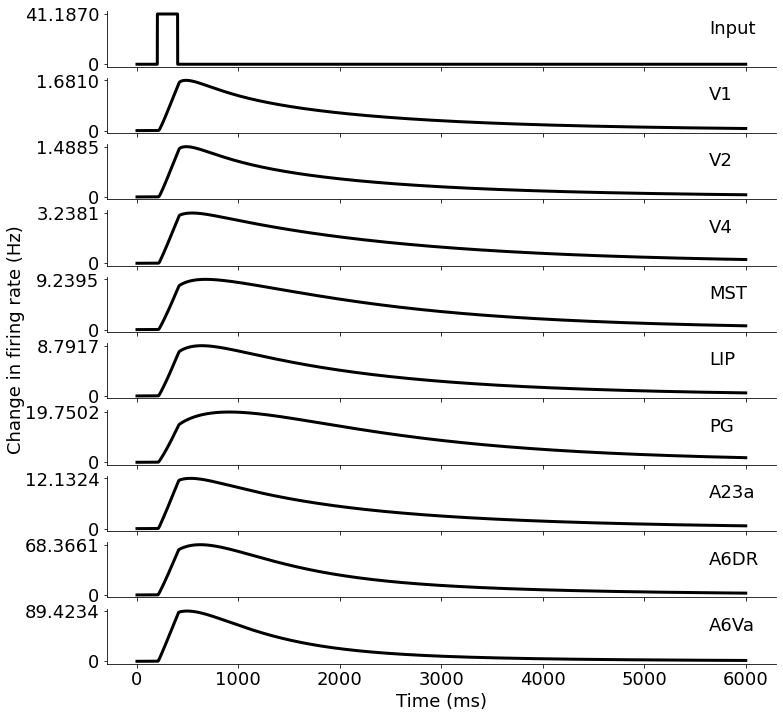

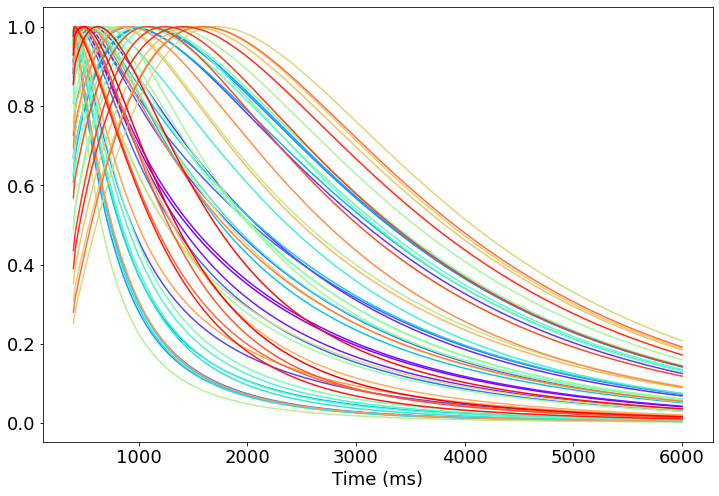

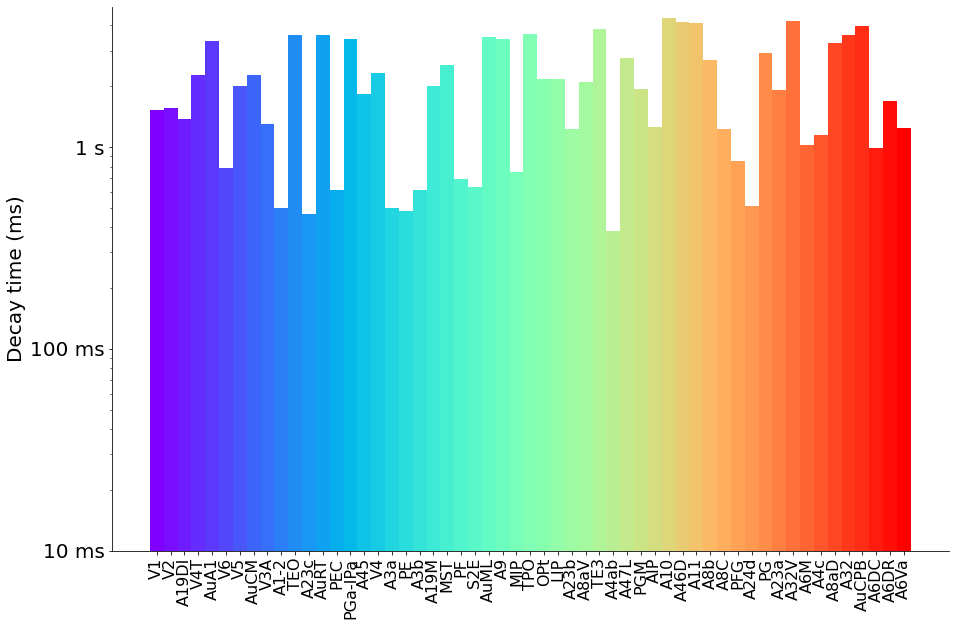

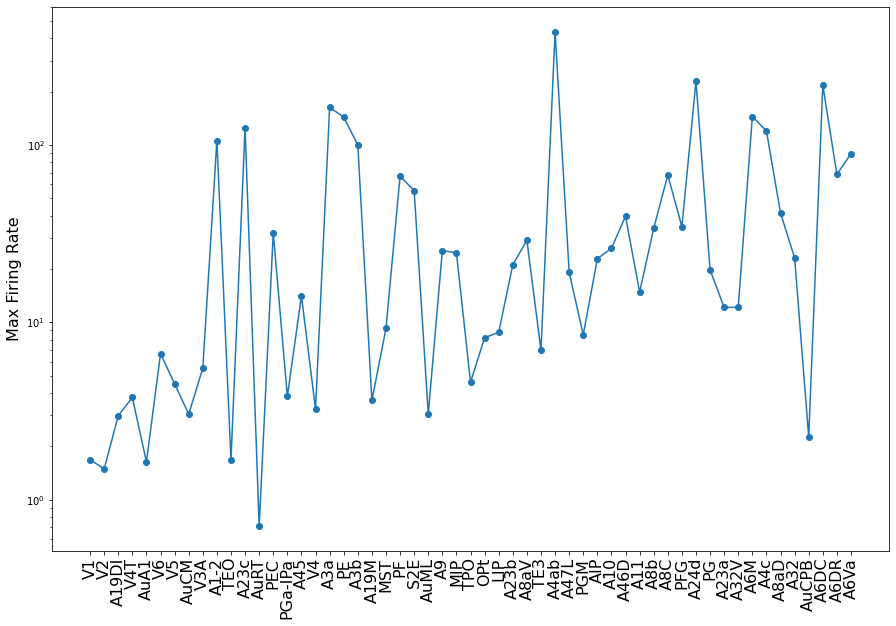

In [5]:
I_stim_exc, r_exc, r_inh, area_stim_idx, dt, t_plot, decay_time, max_rate, f \
= pf.run_stimulus_delay(p,VISUAL_INPUT=1,TOTAL_INPUT=0, MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,CONSENSUS_CASE=0, stim_area='A4ab', plot_Flag=1)

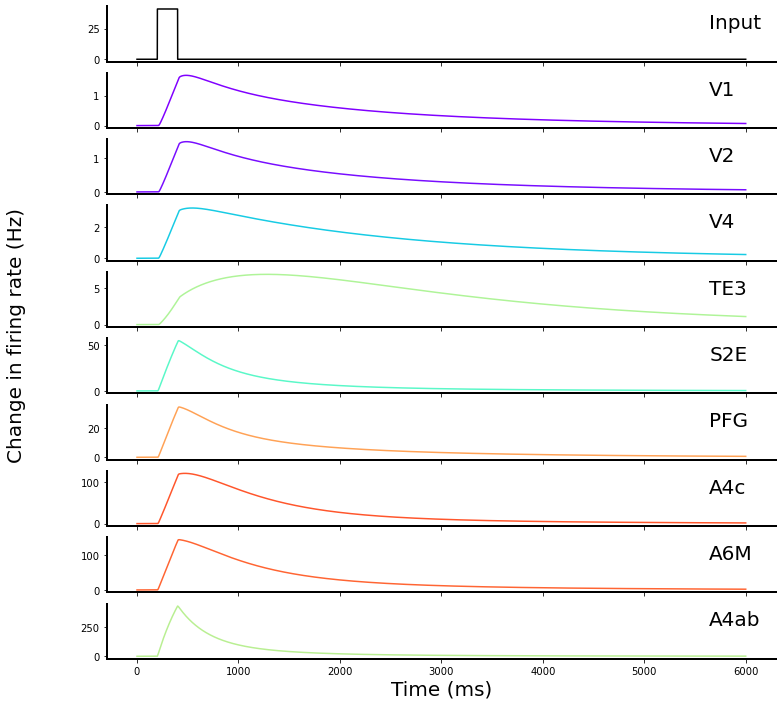

In [6]:
area_name_list = ['V1','V2','V4','TE3', 'S2E','PFG','A4c','A6M','A4ab']
fig = TCP.plot_dynamics(p, r_exc, r_inh, I_stim_exc, area_stim_idx, area_name_list, t_plot, PULSE_INPUT=1)
# TCP.save_fig('Figures/signal_prop_A4ab_delay')

## Compare with Experiment Data (Peak magnitude)

(10, 1000)

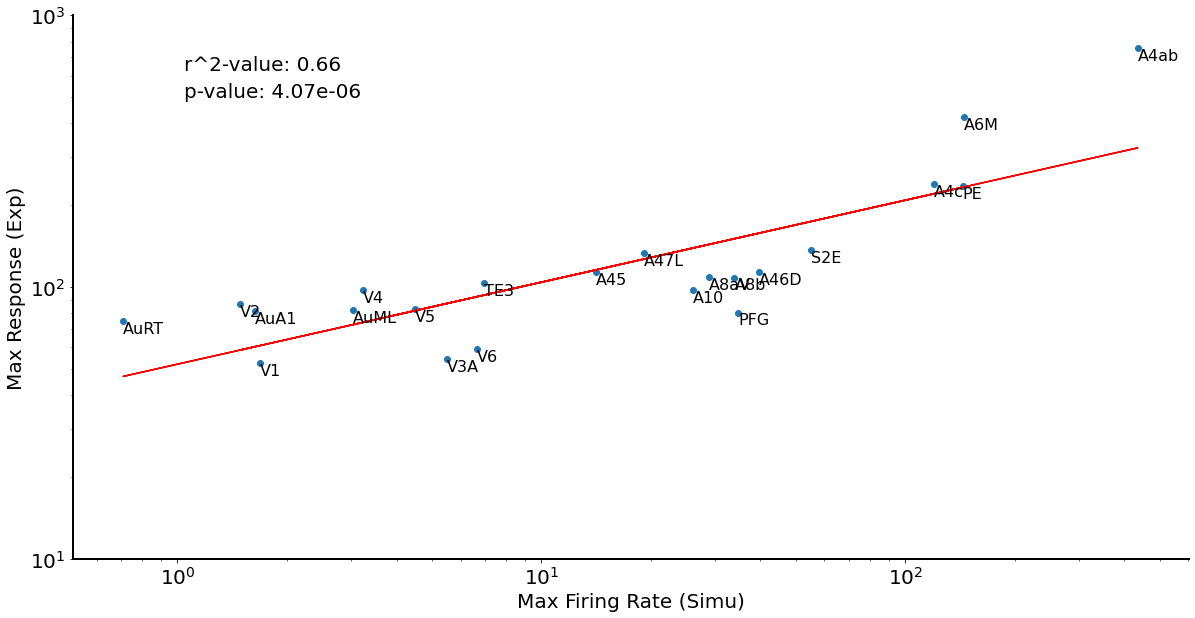

In [7]:
from scipy import stats

fig, ax = plt.subplots(figsize=(20,10), facecolor=(1, 1, 1))
mag_lst_aligned = mag_mat_aligned[4,:]
index_sel = mag_lst_aligned != 0 # np.arange(len(mag_lst_aligned)) # mag_lst_aligned != 0
max_rate_sel = max_rate[index_sel]
mag_lst_sel = mag_lst_aligned[index_sel]
areas_sel = np.array(p['areas'])[index_sel]
plt.scatter(max_rate_sel , mag_lst_sel)
for i in range(len(areas_sel)):
    plt.annotate(areas_sel[i], (max_rate_sel[i], mag_lst_sel[i]), rotation=0,
                 horizontalalignment='left', verticalalignment='top',
                 fontsize = 16)
plt.xscale('log')
plt.yscale('log')
# corr = np.corrcoef(max_rate[mag_lst_aligned != 0], mag_lst_aligned[mag_lst_aligned != 0])[0,1]
# plt.title('Response after stimulus to A4ab, Corr = {:.2f}'.format(corr), fontsize=20)
plt.xlabel('Max Firing Rate (Simu)', fontsize=20)
plt.ylabel('Max Response (Exp)', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(np.log10(max_rate_sel), np.log10(mag_lst_sel))
plt.plot(max_rate_sel, np.power(10, slope*np.log10(max_rate_sel) + intercept), color='red') 
# Print the p-value on the figure
r2_value = np.power(r_value, 2)
plt.text(0.1, 0.9, f'r^2-value: {r2_value:.2f}', transform=plt.gca().transAxes, fontsize=20)
plt.text(0.1, 0.85, f'p-value: {p_value:.2e}', transform=plt.gca().transAxes, fontsize=20)
# Hide the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make the bottom and left spines thicker
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
plt.ylim([10, 1000])
# TCP.save_fig('Figures/cmp_signal_prop_A4ab_delay')

# Fig B: Comparison of model's response after stimulus to A4ab with experiment data

## Model's response after stimulus to V1

In [8]:
p = pf.load_data(datafile)
fln_mat = p['fln_mat'].copy()

p, W = pf.genetate_net_connectivity(p.copy(),FIT_HIER=1, LINEAR_HIER=0,IDENTICAL_HIER=0, LOCAL_IDENTICAL_HIERARCHY=0,ZERO_FLN=0,
                                    IDENTICAL_FLN=0,SHUFFLE_FLN=0,SHUFFLE_TYPE=0,STRONG_GBA=0,
                                    MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,LONGRANGE_EI_ASYMMETRY=0,CONSENSUS_CASE=CONSENSUS_CASE,
                                    diverse_hi=41)
dist_mat,full_dist_mat = pf.generate_dist_matrix(p, MACAQUE_CASE=MACAQUE_CASE, CONSENSUS_CASE=CONSENSUS_CASE)
speed = 3.5  # axonal conduction velocity
delay_mat = dist_mat[0:-1, 0:-1] / speed
p['delay_mat'] = delay_mat

I_stim_exc, r_exc_delay, r_inh, area_stim_idx, dt, t_plot, decay_time, max_rate \
 = pf.run_stimulus_delay(p,VISUAL_INPUT=1,TOTAL_INPUT=0,T=220,PULSE_INPUT=1, MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,CONSENSUS_CASE=0,plot_Flag=0)

Initializing Model. From subgraph_data_marmoset.pkl load:
dict_keys(['fln_mat', 'sln_mat', 'hier_vals', 'areas'])
CONSENSUS_CASE=0
No STRONG GBA
In generate_dist_matrix, CONSENSUS_CASE= 0
Running network with stimulation to V1   PULSE_INPUT=1   MACAQUE_CASE=0


In [9]:
# area_name_list = ['V1','V2','V4','MST','LIP','PG','A23a','A6DR','A6Va']
# fig = TCP.plot_dynamics(p, r_exc, r_inh, I_stim_exc, area_stim_idx, area_name_list, t_plot, PULSE_INPUT=1)
# plt.xlim([190, 230])
# TCP.save_fig('Figures/signal_prop_V1_delay')

In [10]:
p = pf.load_data(datafile)
fln_mat = p['fln_mat'].copy()

p, W = pf.genetate_net_connectivity(p.copy(),FIT_HIER=1, LINEAR_HIER=0,IDENTICAL_HIER=0, LOCAL_IDENTICAL_HIERARCHY=0,ZERO_FLN=0,
                                    IDENTICAL_FLN=0,SHUFFLE_FLN=0,SHUFFLE_TYPE=0,STRONG_GBA=0,
                                    MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,LONGRANGE_EI_ASYMMETRY=0,CONSENSUS_CASE=CONSENSUS_CASE,
                                    diverse_hi=41)
dist_mat,full_dist_mat = pf.generate_dist_matrix(p, MACAQUE_CASE=MACAQUE_CASE, CONSENSUS_CASE=CONSENSUS_CASE)
speed = 3.5  # axonal conduction velocity
delay_mat = dist_mat[0:-1, 0:-1] / speed
p['delay_mat'] = delay_mat

I_stim_exc, r_exc_nodelay, r_inh, area_stim_idx, dt, t_plot, decay_time, max_rate \
 = pf.run_stimulus(p,VISUAL_INPUT=1,TOTAL_INPUT=0,T=220,PULSE_INPUT=1, MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,CONSENSUS_CASE=0,plot_Flag=0)

Initializing Model. From subgraph_data_marmoset.pkl load:
dict_keys(['fln_mat', 'sln_mat', 'hier_vals', 'areas'])
CONSENSUS_CASE=0
No STRONG GBA
In generate_dist_matrix, CONSENSUS_CASE= 0
Running network with stimulation to V1   PULSE_INPUT=1   MACAQUE_CASE=0


(195.0, 220.0)

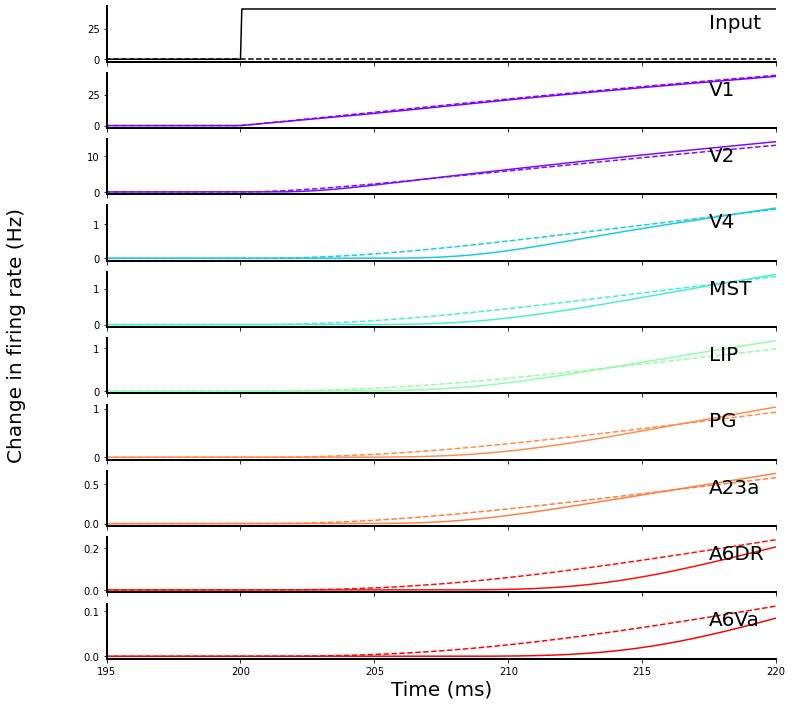

In [11]:
area_name_list = ['V1','V2','V4','MST','LIP','PG','A23a','A6DR','A6Va']
fig = TCP.plot_dynamics_cmp(p, r_exc_delay, r_exc_nodelay, I_stim_exc, area_stim_idx, area_name_list, t_plot, PULSE_INPUT=1)
plt.xlim([195, 220])
# TCP.save_fig('Figures/signal_prop_V1_cmp_delay')

## Model's response after stimulus to AuA1

Initializing Model. From subgraph_data_marmoset.pkl load:
dict_keys(['fln_mat', 'sln_mat', 'hier_vals', 'areas'])
CONSENSUS_CASE=0
No STRONG GBA
In generate_dist_matrix, CONSENSUS_CASE= 0
Running network with stimulation to AuA1   PULSE_INPUT=1   MACAQUE_CASE=0


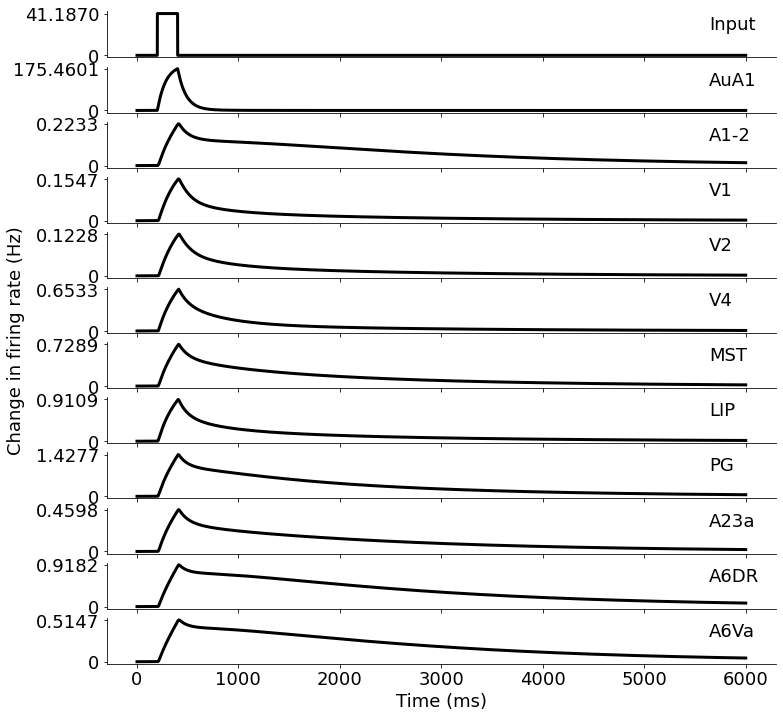

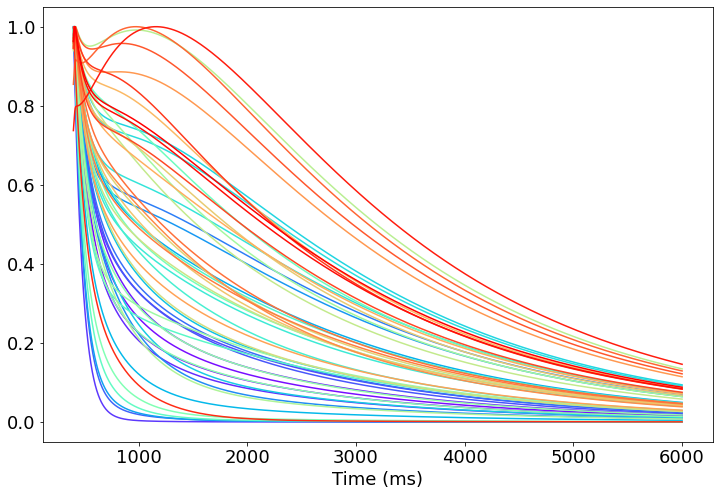

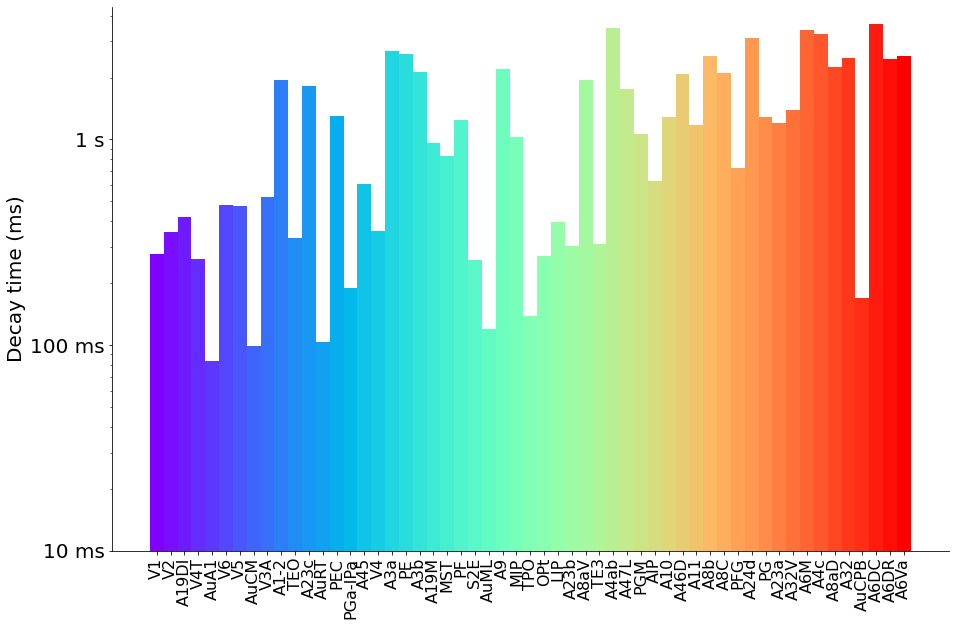

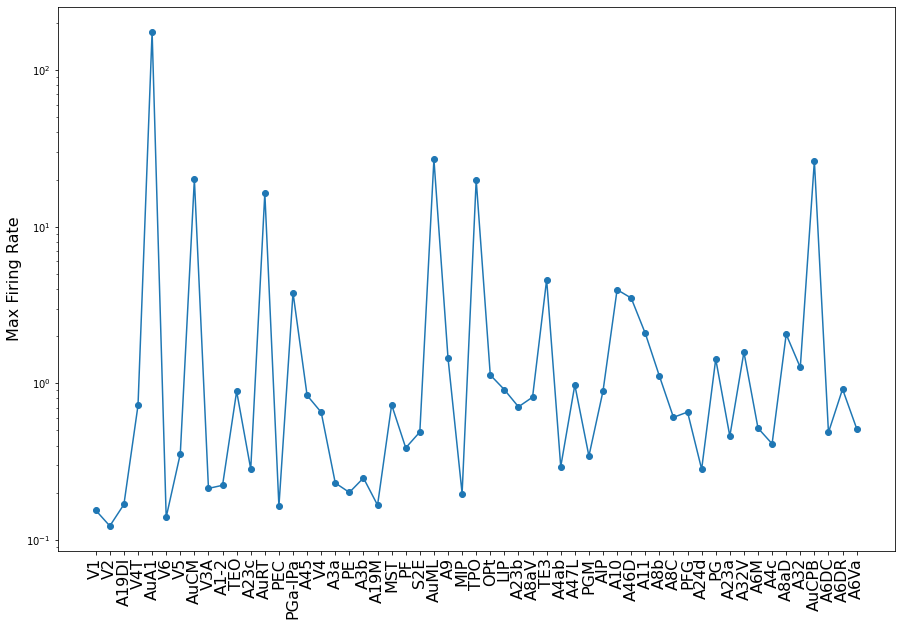

In [12]:
p = pf.load_data(datafile)
fln_mat = p['fln_mat'].copy()

p, W = pf.genetate_net_connectivity(p.copy(),FIT_HIER=1, LINEAR_HIER=0,IDENTICAL_HIER=0, LOCAL_IDENTICAL_HIERARCHY=0,ZERO_FLN=0,
                                    IDENTICAL_FLN=0,SHUFFLE_FLN=0,SHUFFLE_TYPE=0,STRONG_GBA=0,
                                    MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,LONGRANGE_EI_ASYMMETRY=0,CONSENSUS_CASE=CONSENSUS_CASE,
                                    diverse_hi=41)
dist_mat,full_dist_mat = pf.generate_dist_matrix(p, MACAQUE_CASE=MACAQUE_CASE, CONSENSUS_CASE=CONSENSUS_CASE)
speed = 3.5  # axonal conduction velocity
delay_mat = dist_mat[0:-1, 0:-1] / speed
p['delay_mat'] = delay_mat

I_stim_exc, r_exc, r_inh, area_stim_idx, dt, t_plot, decay_time, max_rate, f\
 = pf.run_stimulus_delay(p,VISUAL_INPUT=0,TOTAL_INPUT=0,T=6000,PULSE_INPUT=1, MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,CONSENSUS_CASE=0,plot_Flag=1)

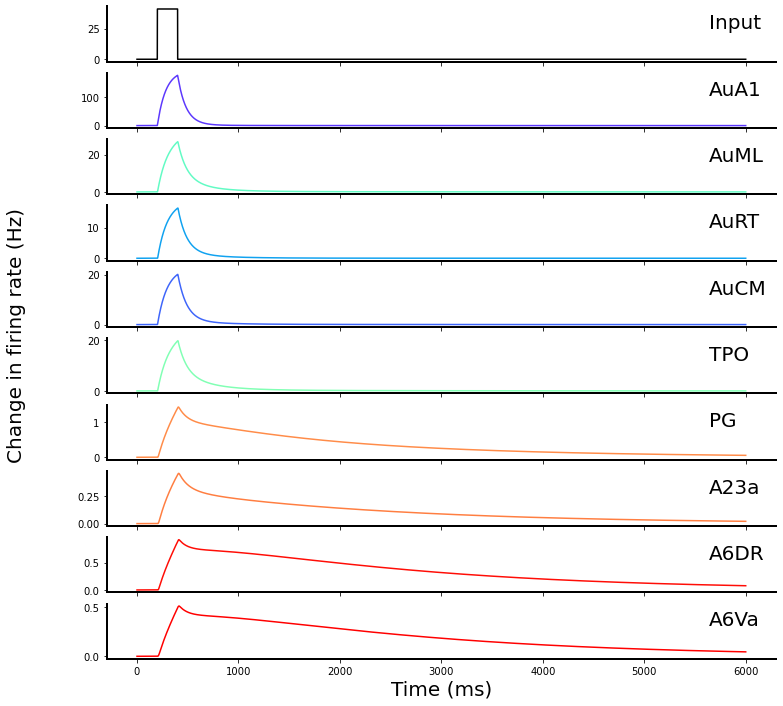

In [13]:
area_name_list = ['AuA1','AuML','AuRT', 'AuCM', 'TPO','PG', 'A23a','A6DR','A6Va']
fig = TCP.plot_dynamics(p, r_exc, r_inh, I_stim_exc, area_stim_idx, area_name_list, t_plot, PULSE_INPUT=1)
# TCP.save_fig('Figures/6B_Supp')

# Resting State Timescale

In [14]:
# # Generate Simulation Data
# # r_exc = pf.plt_white_noise_input(p,VISUAL_INPUT=1,MACAQUE_CASE=MACAQUE_CASE)
# p = pf.load_data(datafile)
# fln_mat = p['fln_mat'].copy()

# p, W = pf.genetate_net_connectivity(p.copy(),FIT_HIER=1, LINEAR_HIER=0,IDENTICAL_HIER=0, LOCAL_IDENTICAL_HIERARCHY=0,ZERO_FLN=0,
#                                     IDENTICAL_FLN=0,SHUFFLE_FLN=0,SHUFFLE_TYPE=0,STRONG_GBA=0,
#                                     MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,LONGRANGE_EI_ASYMMETRY=0,CONSENSUS_CASE=CONSENSUS_CASE,
#                                     diverse_hi=4)
# dist_mat,full_dist_mat = pf.generate_dist_matrix(p, MACAQUE_CASE=MACAQUE_CASE, CONSENSUS_CASE=CONSENSUS_CASE)
# speed = 3.5  # axonal conduction velocity
# delay_mat = dist_mat[0:-1, 0:-1] / speed
# p['delay_mat'] = delay_mat

# I_stim_exc, r_exc, r_inh, area_stim_idx, dt, t_plot, decay_time, max_rate, f\
#  = pf.run_stimulus_delay(p,VISUAL_INPUT=1,TOTAL_INPUT=1,T=2000*1000,PULSE_INPUT=0, MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,CONSENSUS_CASE=0,plot_Flag=1)
                         
# r_exc_sample = r_exc[0::20]

# np.save('Data/Marmoset_Model/r_exc_full_delay.npy', r_exc_sample)

In [15]:
# # Generate Simulation Data
# # r_exc = pf.plt_white_noise_input(p,VISUAL_INPUT=1,MACAQUE_CASE=MACAQUE_CASE)
# p = pf.load_data(datafile)
# fln_mat = p['fln_mat'].copy()

# p, W = pf.genetate_net_connectivity(p.copy(),FIT_HIER=1, LINEAR_HIER=0,IDENTICAL_HIER=0, LOCAL_IDENTICAL_HIERARCHY=0,ZERO_FLN=0,
#                                     IDENTICAL_FLN=0,SHUFFLE_FLN=0,SHUFFLE_TYPE=0,STRONG_GBA=0,
#                                     MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,LONGRANGE_EI_ASYMMETRY=0,CONSENSUS_CASE=CONSENSUS_CASE,
#                                     diverse_hi=4)
# dist_mat,full_dist_mat = pf.generate_dist_matrix(p, MACAQUE_CASE=MACAQUE_CASE, CONSENSUS_CASE=CONSENSUS_CASE)
# speed = 3.5  # axonal conduction velocity
# delay_mat = dist_mat[0:-1, 0:-1] / speed
# p['delay_mat'] = 0.0*delay_mat

# I_stim_exc, r_exc, r_inh, area_stim_idx, dt, t_plot, decay_time, max_rate, f\
#  = pf.run_stimulus_delay(p,VISUAL_INPUT=1,TOTAL_INPUT=1,T=2000*1000,PULSE_INPUT=0, MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,CONSENSUS_CASE=0,plot_Flag=1)
                         
# r_exc_sample = r_exc[0::20]

# np.save('Data/Marmoset_Model/r_exc_full_nodelay.npy', r_exc_sample)

In [16]:
data_resting_simu_delay = np.load('Data/Marmoset_Model/r_exc_full_delay.npy')
df_Model = pd.read_excel('Data/Marmoset_Model/Area_map_Marmoset_W.xlsx')
tau_lst_simu_delay, fok_lst_simu_delay = TCP.compute_time_constant(data_resting_simu_delay.T, df_Model['Area'], df_Model['Area'])

[m, n] = np.shape(data_resting_simu_delay)
data_length = m / 1000 # Seconds
print(data_length)

2000.001


In [17]:
data_resting_simu = np.load('Data/Marmoset_Model/r_exc_full.npy')
df_Model = pd.read_excel('Data/Marmoset_Model/Area_map_Marmoset_W.xlsx')
tau_lst_simu, fok_lst_simu = TCP.compute_time_constant(data_resting_simu.T, df_Model['Area'], df_Model['Area'])

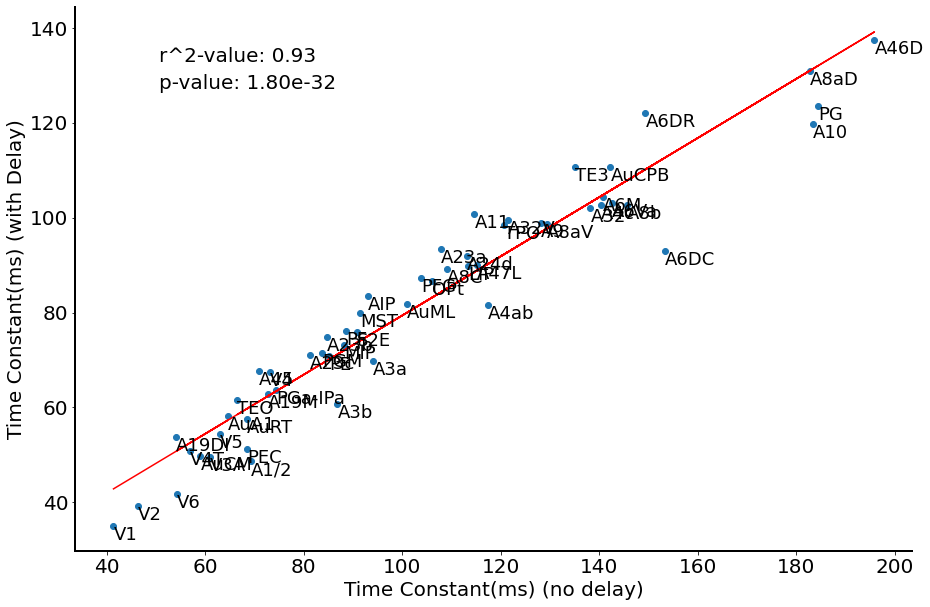

In [18]:
fig = TCP.plot_tau_feature(tau_lst_simu_delay, tau_lst_simu, df_Model['Area'],
        x_label='Time Constant(ms) (no delay)', y_label='Time Constant(ms) (with Delay)',
        annotate_flag=True, log_flag=False)
# plt.ylim([10, 50])
# TCP.save_fig('Figures/timescale_cmp_delay_nodelay')

In [19]:
data_resting_simu = np.load('Data/Marmoset_Model/r_exc_full_delay.npy')

import statsmodels.tsa.api as smt
T_lag = int(3e3)
acf_data = np.zeros([p['n_area'],T_lag+1])
for j in np.arange(p['n_area']):
    acf_data[j,:] = smt.stattools.acf(data_resting_simu[:, j], nlags=T_lag, fft=True)

Text(0.5, 1.0, 'input loc and corr measure at the same area')

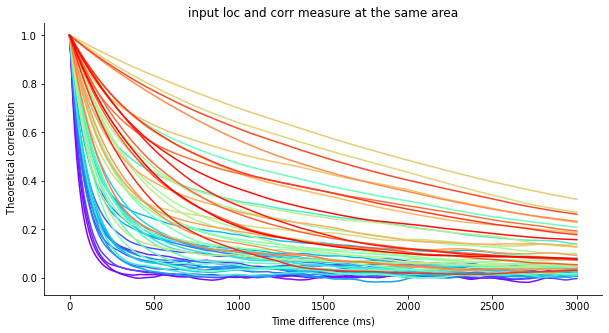

In [20]:
import matplotlib.cm as cm
clist = cm.get_cmap(plt.get_cmap('rainbow'))(np.linspace(0.0, 1.0, p['n_area']))[np.newaxis, :, :3]

plt.figure(figsize=(10,5), facecolor=(1, 1, 1))
ax = plt.axes()
for i in np.arange(p['n_area']):
    plt.plot(np.arange(T_lag+1),np.real(acf_data[i,:]),color=clist[0][i])

# plt.legend(area_name_list)
plt.xlabel('Time difference (ms)')
plt.ylabel(' Theoretical correlation')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title('input loc and corr measure at the same area')
# TCP.save_fig('Figures/timescale_acf_delay')

(0.0, 55.0)

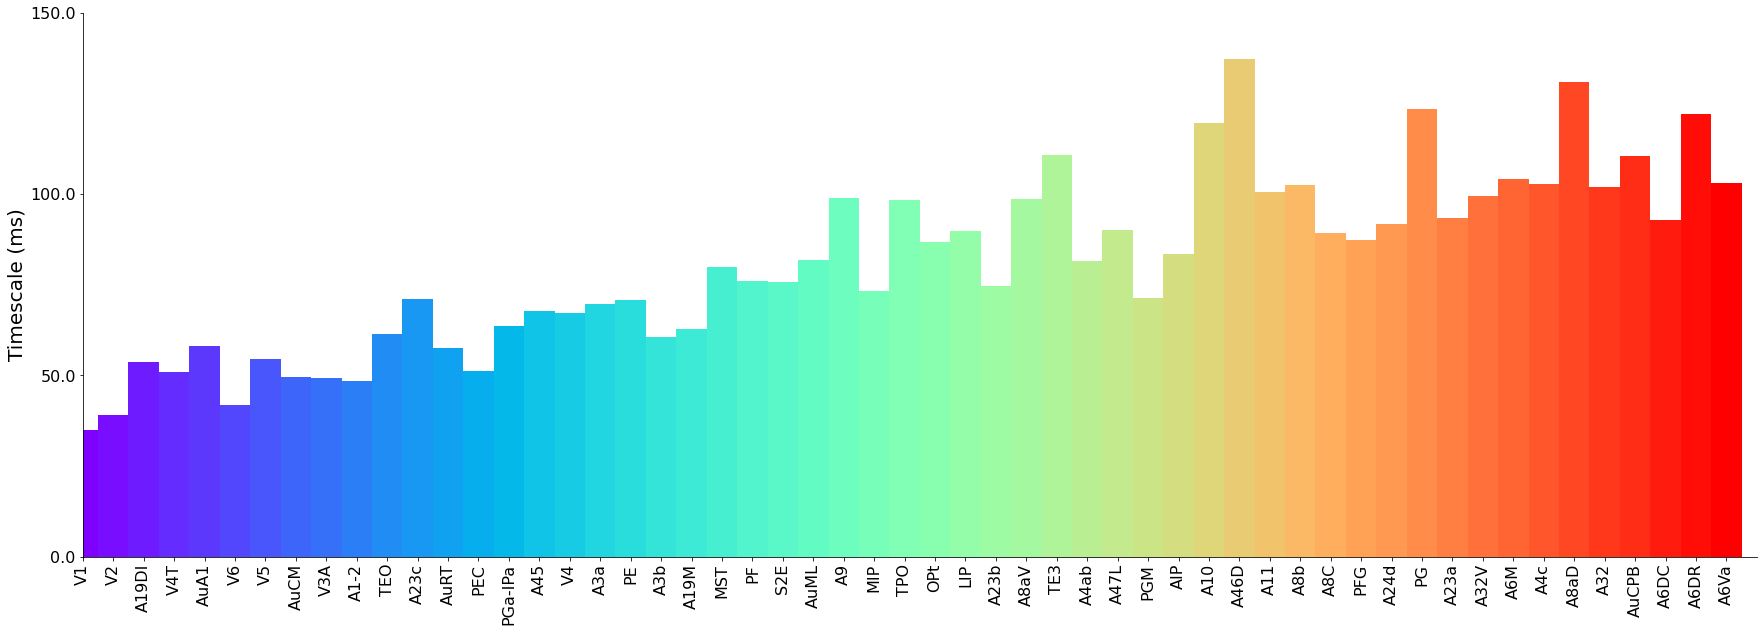

In [21]:
fig, ax=plt.subplots(figsize=(30,10), facecolor=(1, 1, 1))
clist = cm.get_cmap(plt.get_cmap('rainbow'))(np.linspace(0.0, 1.0, p['n_area']))[np.newaxis, :, :3]
ax.bar(np.arange(len(p['areas'])), tau_lst_simu_delay,width = 1,color=clist[0])
ax.set_xticks(np.arange(len(p['areas'])))
ax.set_yticks(np.linspace(0, 150, 4))
ax.set_yticklabels(np.linspace(0, 150, 4),fontsize=16)
ax.set_xticklabels(p['areas'],rotation=90,fontsize=16)
# plt.yticks([10,100,1000],['10 ms','100 ms','1 s'],rotation=0)
ax.set_ylabel('Timescale (ms)',fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim((0, p['n_area']))
# TCP.save_fig('Figures/timescale_bar_delay')